# Section 5 — Collections Strategy

**Purpose:** Use the trained model's predictions to segment customers into risk tiers and generate business-ready collections recommendations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression

PROCESSED_DIR = "../data/processed"
FIGURES_DIR   = "../reports/figures"

# Load test data
X_test  = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_test  = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze()
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze()

# Retrain model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Model ready.")
print(f"Test records : {X_test.shape[0]:,}")

Model ready.
Test records : 6,000


### Risk Tier

In [6]:
# Get predicted probabilities instead of just 0/1
y_prob = model.predict_proba(X_test)[:, 1]

# Build results DataFrame
results_df = pd.DataFrame({
    "actual_delinquent"    : y_test.values,
    "delinquency_probability": y_prob.round(3)
})

# Assign risk tier based on probability score
def assign_tier(prob):
    if prob >= 0.70:
        return "Critical"
    elif prob >= 0.50:
        return "High"
    elif prob >= 0.30:
        return "Medium"
    else:
        return "Low"

results_df["risk_tier"] = results_df["delinquency_probability"].apply(assign_tier)

print("Risk tiers assigned.")
print()
print(results_df["risk_tier"].value_counts().to_string())

Risk tiers assigned.

risk_tier
Low         4911
Medium       649
High         368
Critical      72


### Risk Tier Summary Chart

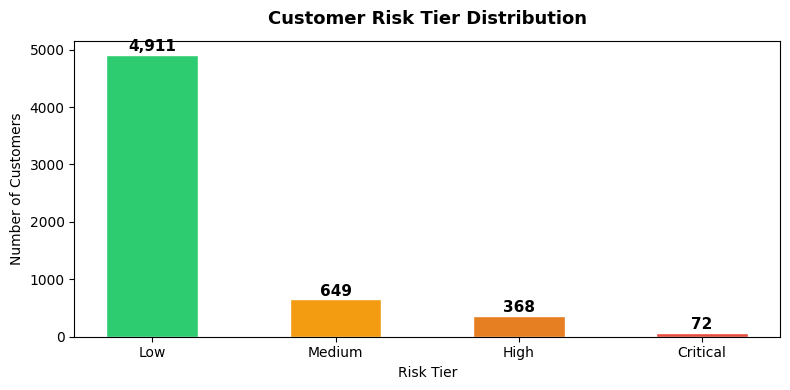

Risk tier chart saved.


In [7]:
tier_order  = ["Low", "Medium", "High", "Critical"]
tier_colors = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]
tier_counts = results_df["risk_tier"].value_counts().reindex(tier_order)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(tier_counts.index, tier_counts.values,
              color=tier_colors, edgecolor="white", width=0.5)

ax.set_title("Customer Risk Tier Distribution",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Risk Tier")
ax.set_ylabel("Number of Customers")

# Add count labels on top of each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "section5_risk_tiers.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Risk tier chart saved.")

# Build business recommendations per risk tier
### Collection strategy table

In [9]:
strategy_data = {
    "Risk Tier"   : ["Low", "Medium", "High", "Critical"],
    "Probability" : ["< 30%", "30% - 50%", "50% - 70%", ">= 70%"],
    "Action"      : [
        "No action — monitor monthly",
        "Send payment reminder email",
        "Outbound call + payment plan offer",
        "Immediate escalation — field agent or legal"
    ],
    "Priority"    : ["Low", "Standard", "High", "Urgent"]
}

strategy_df = pd.DataFrame(strategy_data)

print("=" * 65)
print("  COLLECTIONS STRATEGY RECOMMENDATIONS BY RISK TIER")
print("=" * 65)
print(strategy_df.to_string(index=False))
print("=" * 65)

# Save to CSV
strategy_df.to_csv(
    os.path.join(PROCESSED_DIR, "collections_strategy_table.csv"),
    index=False
)
print("\nStrategy table saved to data/processed/")

  COLLECTIONS STRATEGY RECOMMENDATIONS BY RISK TIER
Risk Tier Probability                                      Action Priority
      Low       < 30%                 No action — monitor monthly      Low
   Medium   30% - 50%                 Send payment reminder email Standard
     High   50% - 70%          Outbound call + payment plan offer     High
 Critical      >= 70% Immediate escalation — field agent or legal   Urgent

Strategy table saved to data/processed/


### Collections Strategy Output
- Model probabilities converted into four actionable risk tiers
- Each tier assigned a specific collections action and priority level
- Strategy table exported as CSV for business stakeholder use

### Dataset
UCI Default of Credit Card Clients — 30,000 records, 25 features  
Source: UCI Machine Learning Repository